Importation de donnees

In [55]:
import pandas as pd
df = pd.read_csv('football.csv')
df_comp=pd.read_csv("competition.csv")

Nettoyage de donnees

In [56]:
df.isna().sum()


id                           0
date                         0
home_team                    0
away_team                    0
rank_change_home             0
rank_change_away          2042
home_goals_mean              0
home_goals_mean_l5           0
home_goals_suf_mean         24
home_goals_suf_mean_l5       0
home_rank_mean               0
home_rank_mean_l5            0
home_points_mean            14
home_points_mean_l5          0
away_goals_mean              0
away_goals_mean_l5           0
away_goals_suf_mean         17
away_goals_suf_mean_l5       0
away_rank_mean               0
away_rank_mean_l5            0
away_points_mean             0
away_points_mean_l5          0
target                       0
match_type                   0
dtype: int64

In [57]:
df = df.drop(columns=['home_team','away_team','rank_change_away','id','date','match_type'])

In [58]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3777 entries, 0 to 3776
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   rank_change_home        3777 non-null   float64
 1   home_goals_mean         3777 non-null   float64
 2   home_goals_mean_l5      3777 non-null   float64
 3   home_goals_suf_mean     3753 non-null   float64
 4   home_goals_suf_mean_l5  3777 non-null   float64
 5   home_rank_mean          3777 non-null   float64
 6   home_rank_mean_l5       3777 non-null   float64
 7   home_points_mean        3763 non-null   float64
 8   home_points_mean_l5     3777 non-null   float64
 9   away_goals_mean         3777 non-null   float64
 10  away_goals_mean_l5      3777 non-null   float64
 11  away_goals_suf_mean     3760 non-null   float64
 12  away_goals_suf_mean_l5  3777 non-null   float64
 13  away_rank_mean          3777 non-null   float64
 14  away_rank_mean_l5       3777 non-null   

In [59]:
df['home_goals_suf_mean'] = df['home_goals_suf_mean'].fillna(df['home_goals_suf_mean'].median())
df['home_points_mean'] = df['home_points_mean'].fillna(df['home_points_mean'].median())
df['away_goals_suf_mean'] = df['away_goals_suf_mean'].fillna(df['away_goals_suf_mean'].median())

Heat map correlation entre colonnes

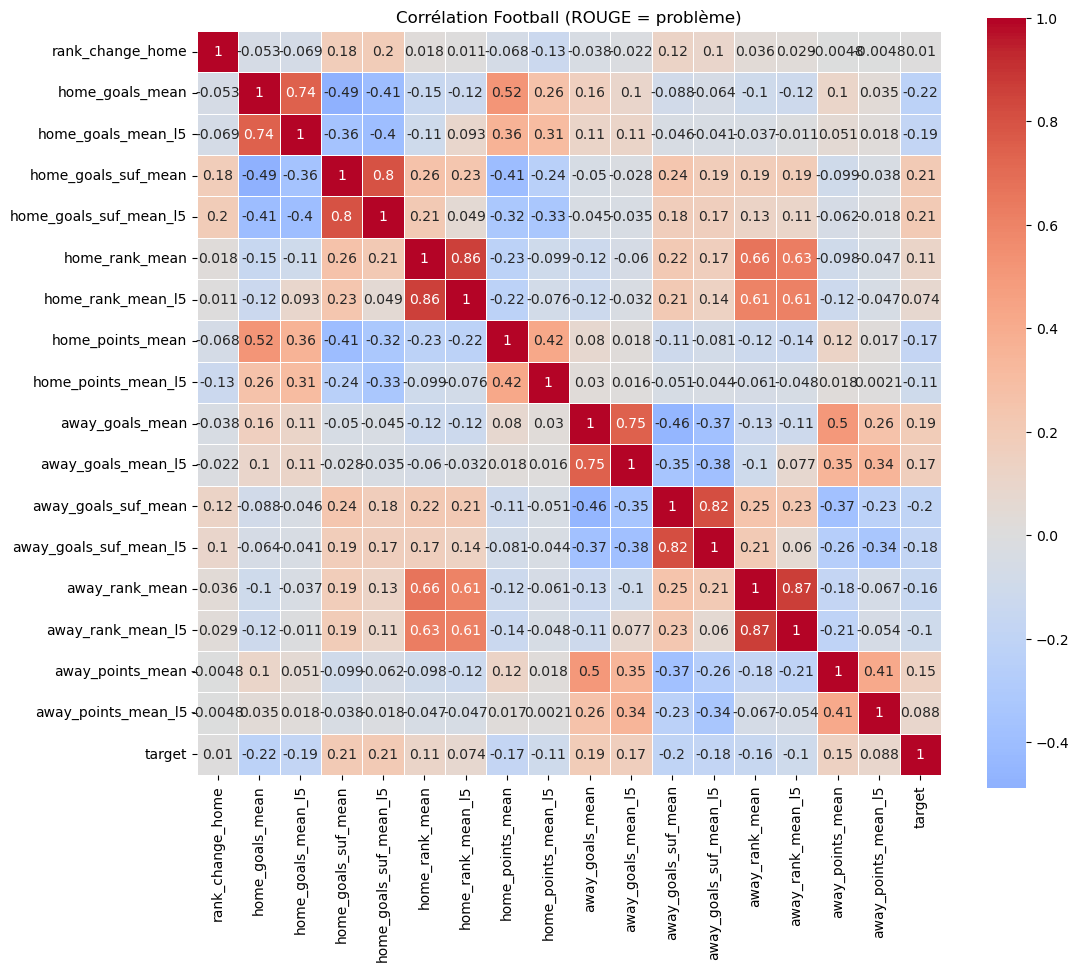

In [60]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_matrix = df.corr()

plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=0.5)
plt.title('Corrélation Football (ROUGE = problème)')
plt.show()

supprime colonne trop grande correlation entre eux

In [61]:
import numpy as np

corr_matrix = df.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [col for col in upper.columns if any(upper[col] > 0.95)]
if to_drop:
    print(f"COLONNE SUPPRIMÉE : {to_drop}")
    print(f"Corrélation avec : {upper.loc[:, to_drop[0]][upper.loc[:, to_drop[0]] > 0.95].index.tolist()}")

df.drop(columns=to_drop, inplace=True)
print(f"Supprimé: {len(to_drop)} colonnes")


Supprimé: 0 colonnes


Les meme data a competition que football

In [62]:
df_comp = df_comp.drop(columns=['home_team','away_team','rank_change_away','match_type','date'])

Standardiser

In [63]:
from sklearn.model_selection import train_test_split
x = df.drop('target', axis=1)
y=df['target']
x_comp = df_comp.drop('id', axis=1)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=3)



scaler les donnees

In [67]:
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)
x_comp_scaled = scaler.transform(x_comp)



Entrainement de donnee svm

In [68]:
svm = SVC(C=1, gamma='scale', random_state=42)
svm.fit(x_train_scaled, y_train)

,C,1
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


test sur la validation

In [69]:
from sklearn.metrics import accuracy_score
y_pred_val = svm.predict(x_test_scaled)
print(f"Accuracy validation: {accuracy_score(y_test, y_pred_val):.3f}")

Accuracy validation: 0.679


prediction sur csv competition

In [76]:
y_comp_pred = svm.predict(x_comp_scaled)

sauvegarder svm

In [77]:
svmsoum = pd.DataFrame({'id': df_comp['id'], 'target': y_comp_pred})
svmsoum.to_csv('submission_svm.csv', index=False)

Visualisation

classification report

In [83]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = svm.predict(x_test_scaled)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.69      0.61      0.65       369
           1       0.67      0.74      0.70       387

    accuracy                           0.68       756
   macro avg       0.68      0.68      0.68       756
weighted avg       0.68      0.68      0.68       756



Confusion map

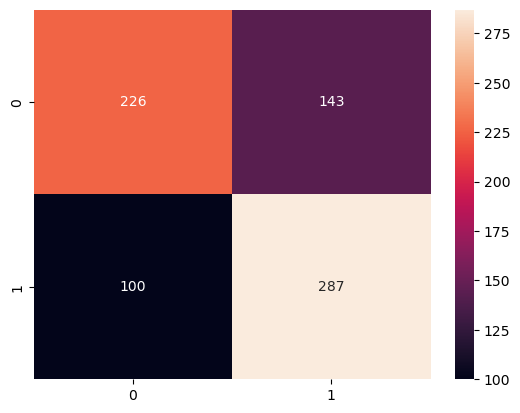

In [84]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')
plt.show()

correlation avec target

In [85]:

corrs = df.corr()['target'].sort_values(ascending=False)
print(corrs.round(3))

target                    1.000
home_goals_suf_mean_l5    0.208
home_goals_suf_mean       0.206
away_goals_mean           0.186
away_goals_mean_l5        0.173
away_points_mean          0.151
home_rank_mean            0.114
away_points_mean_l5       0.088
home_rank_mean_l5         0.074
rank_change_home          0.010
away_rank_mean_l5        -0.103
home_points_mean_l5      -0.110
away_rank_mean           -0.156
home_points_mean         -0.170
away_goals_suf_mean_l5   -0.181
home_goals_mean_l5       -0.186
away_goals_suf_mean      -0.195
home_goals_mean          -0.216
Name: target, dtype: float64


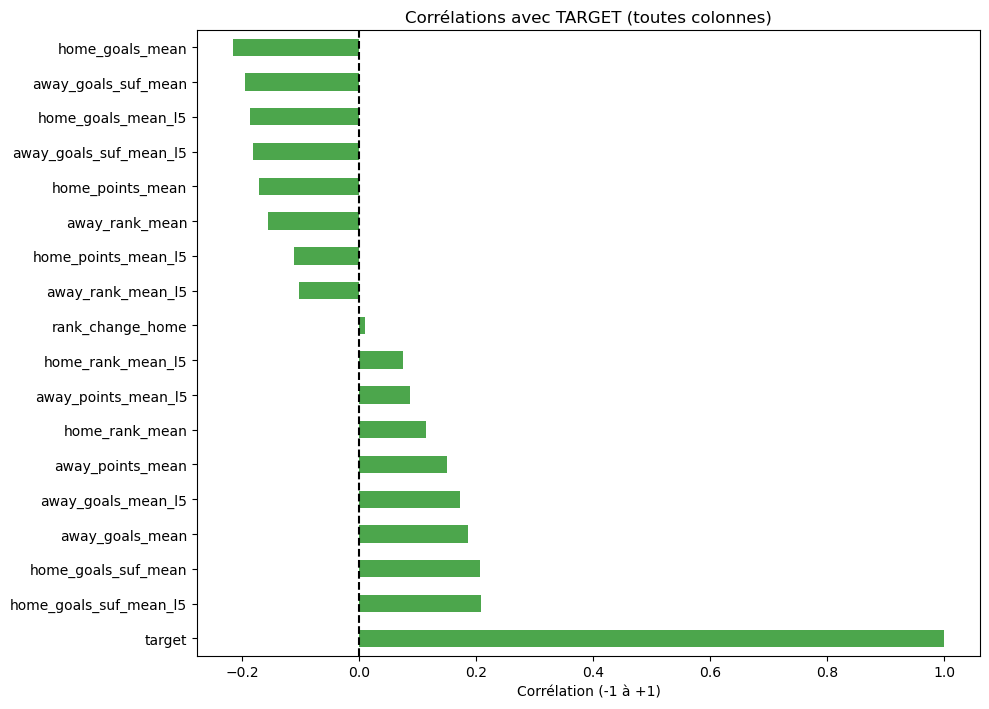

In [86]:
plt.figure(figsize=(10, len(df.columns)*0.4))
corrs.plot(kind='barh', color='green', alpha=0.7)
plt.title('Corrélations avec TARGET (toutes colonnes)')
plt.xlabel('Corrélation (-1 à +1)')
plt.axvline(x=0, color='black', linestyle='--')
plt.tight_layout()
plt.show()


In [87]:
# CORRÉLATION + SUPPRESSION DÉTAILLÉE
print("🔍 Analyse corrélation avec 'target' (>0.10)...")

corr = df.corr()['target'].abs()
garder = corr[corr > 0.10].index.tolist()

# **NOUVEAU** : Liste des colonnes SUPPRIMÉES (correlation < 0.10)
supprimees = [col for col in df.columns if col not in garder]
print(f"\n❌ **COLONNES SUPPRIMÉES** (corr < 0.10):")
for col in supprimees:
    corr_val = corr[col]
    print(f"   → {col}: {corr_val:.3f}")

print(f"\n📊 {len(df.columns)} → {len(garder)} colonnes gardées")
print(f"🗑️  {len(supprimees)} colonnes supprimées")

# DataFrame nettoyé
df_clean = df[garder]
print("\n📈 Corrélations restantes (triées):")
print(df_clean.corr()['target'].sort_values(ascending=False))

df = df_clean
print("\n✅ Nettoyage terminé !")


🔍 Analyse corrélation avec 'target' (>0.10)...

❌ **COLONNES SUPPRIMÉES** (corr < 0.10):
   → rank_change_home: 0.010
   → home_rank_mean_l5: 0.074
   → away_points_mean_l5: 0.088

📊 18 → 15 colonnes gardées
🗑️  3 colonnes supprimées

📈 Corrélations restantes (triées):
target                    1.000000
home_goals_suf_mean_l5    0.208255
home_goals_suf_mean       0.206263
away_goals_mean           0.186174
away_goals_mean_l5        0.173048
away_points_mean          0.150900
home_rank_mean            0.113817
away_rank_mean_l5        -0.102771
home_points_mean_l5      -0.110375
away_rank_mean           -0.156152
home_points_mean         -0.170279
away_goals_suf_mean_l5   -0.181350
home_goals_mean_l5       -0.185658
away_goals_suf_mean      -0.195170
home_goals_mean          -0.216160
Name: target, dtype: float64

✅ Nettoyage terminé !


In [88]:
df_comp = df_comp.drop(columns=['rank_change_home','home_rank_mean_l5','away_points_mean_l5'])

modele 2 SVM

In [95]:
scaler2 = StandardScaler()
x_train_scaled2 = scaler2.fit_transform(x_train)
x_test_scaled2 = scaler2.transform(x_test)
x_comp_scaled2 = scaler2.transform(x_comp)

In [103]:
svm2 = SVC(C=10, gamma=0.01, class_weight='balanced', random_state=1)
svm2.fit(x_train_scaled2, y_train)


,C,10
,kernel,'rbf'
,degree,3
,gamma,0.01
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,'balanced'
,verbose,False


In [112]:
y_pred_2 = svm2.predict(x_test_scaled2)
print(f"SVM2: {accuracy_score(y_test, y_pred_2):.3f}")
print(classification_report(y_test, y_pred_2))

SVM2: 0.676
              precision    recall  f1-score   support

           0       0.67      0.67      0.67       369
           1       0.68      0.68      0.68       387

    accuracy                           0.68       756
   macro avg       0.68      0.68      0.68       756
weighted avg       0.68      0.68      0.68       756



In [ ]:
y_comp_pred2 = svm2.predict(x_comp_scaled2)


In [114]:
svmsoum2 = pd.DataFrame({'id': df_comp['id'], 'target': y_comp_pred2})
svmsoum2.to_csv('submission_svm2.csv', index=False)
print("✅ SVM2 submission.csv créé !")

✅ SVM2 submission.csv créé !


Modele 3 SVM

In [115]:
scaler3 = StandardScaler()
x_train_scaled3 = scaler3.fit_transform(x_train)
x_test_scaled3 = scaler3.transform(x_test)
x_comp_scaled3 = scaler3.transform(x_comp)

In [116]:
svm3 = SVC(C=100, gamma=0.001, class_weight='balanced', random_state=42)
svm3.fit(x_train_scaled3, y_train)
y_pred_3 = svm3.predict(x_test_scaled3)
print(f"SVM2: {accuracy_score(y_test, y_pred_3):.3f}")
print(classification_report(y_test, y_pred_3))

SVM2: 0.693
              precision    recall  f1-score   support

           0       0.68      0.69      0.69       369
           1       0.70      0.70      0.70       387

    accuracy                           0.69       756
   macro avg       0.69      0.69      0.69       756
weighted avg       0.69      0.69      0.69       756



In [117]:
y_comp_pred2 = svm2.predict(x_comp_scaled3)
svmsoum3 = pd.DataFrame({'id': df_comp['id'], 'target': y_comp_pred2})
svmsoum3.to_csv('submission_svm3.csv', index=False)


✅ SVM2 submission.csv créé !


Cross_validation (Si overfitting)

In [118]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(SVC(C=1, random_state=42), x_scaled, y, cv=5)
print(scores.mean(), '+', scores.std())


0.6944738778513614 + 0.013830573162881185
